# P0-3 — Smoke-test price pull: NEMOSIS vs OpenElectricity

**Goal:** pull one week of `VIC1` 5-minute spot price from the two independent
sources this project relies on, overlay them on **one** plot, and quantify the gap —
so we can judge whether the sources agree before building the data layer on them.

- **NEMOSIS** → historical AEMO NEMweb `DISPATCHPRICE` table (the *primary* source).
- **OpenElectricity** → OpenNEM API `price` metric (the *independent* cross-check).

> The scaffolding here — the pulls, the time alignment, the plot — is agent-built.
> **The verdict in §5 (do they agree, and why) is the owner's**, per the CLAUDE.md
> delegation boundary: NEM interpretation and "whether two data sources agree" is 🧠 owner-only.
> Re-run this yourself and make sure you can explain every cell before it counts as done.

**Kernel:** select the project venv (`.venv`, Python 3.12), then run top-to-bottom.

## 0. Setup & config

Change `REGION` / `START` / `END` to pull a different slice.

In [1]:
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# --- Config: edit these to pull a different region / window ---
REGION = "VIC1"
START = datetime(2025, 6, 2)      # inclusive
END = datetime(2025, 6, 9)        # exclusive (one week)
INTERVAL = "5m"

# Resolve repo root whether run from notebooks/ or the repo root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NEMOSIS_CACHE = PROJECT_ROOT / "data" / "nemosis_cache"   # gitignored CSV/feather cache
FIGURES = PROJECT_ROOT / "figures"
NEMOSIS_CACHE.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(exist_ok=True)

# NEMOSIS wants 'YYYY/MM/DD HH:MM:SS' strings
NEM_START = START.strftime("%Y/%m/%d %H:%M:%S")
NEM_END = END.strftime("%Y/%m/%d %H:%M:%S")

load_dotenv(PROJECT_ROOT / ".env")   # puts OPENELECTRICITY_API_KEY on the environment
print(f"Region {REGION} | {START:%Y-%m-%d} -> {END:%Y-%m-%d} | interval {INTERVAL}")

Region VIC1 | 2025-06-02 -> 2025-06-09 | interval 5m


## 1. NEMOSIS — historical AEMO dispatch price

Pulls the `DISPATCHPRICE` table and keeps the regional reference price (`RRP`).

- `SETTLEMENTDATE` is **interval-ending** and in **NEM time** (AEST, UTC+10, no DST),
  stored **tz-naive**. We rename it to `time` and carry it as our common index.
- ⚠ AEMO migrated the NEMweb endpoints in April 2026 — if this 404s, see the CLAUDE.md
  data-layer caveat (pin a NEMOSIS version / fall back to OpenElectricity).

In [2]:
from nemosis import dynamic_data_compiler

nem_raw = dynamic_data_compiler(
    NEM_START, NEM_END, "DISPATCHPRICE", str(NEMOSIS_CACHE),
    select_columns=["SETTLEMENTDATE", "REGIONID", "RRP"],
    filter_cols=["REGIONID"], filter_values=([REGION],),
    fformat="feather",
)

nemosis = (
    nem_raw.rename(columns={"SETTLEMENTDATE": "time", "RRP": "nemosis"})
           .loc[:, ["time", "nemosis"]]
           .sort_values("time")
           .reset_index(drop=True)
)
print(nemosis.shape)
nemosis.head()

INFO: Compiling data for table DISPATCHPRICE


/home/andy/wiki/projects/nem-battery-sim/.venv/lib/python3.12/site-packages/pandas/io/feather_format.py:178: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  pa_table = feather.read_table(


INFO: Returning DISPATCHPRICE.


(2016, 2)


,time,nemosis
0,2025-06-02 00:05:00,51.36440
1,2025-06-02 00:10:00,67.09567
2,2025-06-02 00:15:00,53.28719
3,2025-06-02 00:20:00,53.00332
4,2025-06-02 00:25:00,19.18996


## 2. OpenElectricity — independent price source

Same region and window from the OpenNEM API. The response is nested
(`response.data[i].results[j].data` → list of `(timestamp, value)`), so we flatten it.

- OE timestamps are **tz-aware (+10:00)**. We convert to `Australia/Brisbane` (AEST,
  no DST) and drop the tz so the index matches NEMOSIS's naive NEM time.
- Free/COMMUNITY tier — keep pulls modest (rate limits).

In [3]:
import logging
from openelectricity import OEClient, MarketMetric

# The client attaches a stdout DEBUG handler at import (ENV defaults to "development");
# clear it and raise the level so the notebook output stays clean.
_oe_log = logging.getLogger("openelectricity")
_oe_log.handlers.clear()
_oe_log.setLevel(logging.WARNING)

with OEClient() as client:                 # reads OPENELECTRICITY_API_KEY from the env
    resp = client.get_market(
        network_code="NEM",
        metrics=[MarketMetric.PRICE],
        interval=INTERVAL,
        date_start=START,
        date_end=END,
        primary_grouping="network_region",
        network_region=REGION,
    )

series = resp.data[0]                       # one NetworkTimeSeries: price, this region
points = series.results[0].data             # list of TimeSeriesDataPoint((time, value))
print("unit:", series.unit, "| tz offset:", series.network_timezone_offset)

oe = pd.DataFrame([p.root for p in points], columns=["time", "openelectricity"])
oe["time"] = (
    pd.to_datetime(oe["time"], utc=True)
      .dt.tz_convert("Australia/Brisbane")  # AEST, no DST — matches NEM settlement time
      .dt.tz_localize(None)                 # drop tz -> naive, to align with NEMOSIS
)
oe = oe.sort_values("time").reset_index(drop=True)
print(oe.shape)
oe.head()

unit: $/MWh | tz offset: +10:00
(2016, 2)


,time,openelectricity
0,2025-06-02 00:00:00,-20.00
1,2025-06-02 00:05:00,51.36
2,2025-06-02 00:10:00,67.10
3,2025-06-02 00:15:00,53.29
4,2025-06-02 00:20:00,53.00


## 3. Align & merge

Inner-join on the shared `time` index and take the difference
(`NEMOSIS − OpenElectricity`). Things to keep an eye on (report, don't paper over):

- **Timestamp convention** — both are treated as interval-ending NEM time here; a
  half-interval offset would show up as a systematic sawtooth in the difference.
- **Window edges** — the sources can differ by one interval at each end; the inner
  join drops those unmatched rows (counted below).
- **Precision** — note how many decimal places each source reports.

In [4]:
merged = (
    pd.merge(nemosis, oe, on="time", how="inner")
      .sort_values("time")
      .reset_index(drop=True)
)
merged["diff"] = merged["nemosis"] - merged["openelectricity"]

n_nem, n_oe, n_m = len(nemosis), len(oe), len(merged)
print(f"NEMOSIS intervals: {n_nem} | OE intervals: {n_oe} | matched: {n_m}")
print(f"unmatched at window edges -> NEMOSIS: {n_nem - n_m}, OE: {n_oe - n_m}")
print("\nDifference (NEMOSIS - OpenElectricity), $/MWh:")
print(merged["diff"].describe()[["mean", "std", "min", "max"]].round(4))
print(f"max |diff| = {merged['diff'].abs().max():.4f} $/MWh")
merged.head()

NEMOSIS intervals: 2016 | OE intervals: 2016 | matched: 2015
unmatched at window edges -> NEMOSIS: 1, OE: 1

Difference (NEMOSIS - OpenElectricity), $/MWh:
mean   -0.0000
std     0.0022
min    -0.0050
max     0.0050
Name: diff, dtype: float64
max |diff| = 0.0050 $/MWh


,time,nemosis,openelectricity,diff
0,2025-06-02 00:05:00,51.36440,51.36,0.00440
1,2025-06-02 00:10:00,67.09567,67.10,-0.00433
2,2025-06-02 00:15:00,53.28719,53.29,-0.00281
3,2025-06-02 00:20:00,53.00332,53.00,0.00332
4,2025-06-02 00:25:00,19.18996,19.19,-0.00004


## 4. Plot — overlay + difference

Both series share **one** `$/MWh` axis (same measure — never a dual y-axis). The
source-to-source difference is a different scale, so it gets its own panel below,
sharing the x-axis.

saved: figures/smoke_test_VIC1_20250602_20250609.png


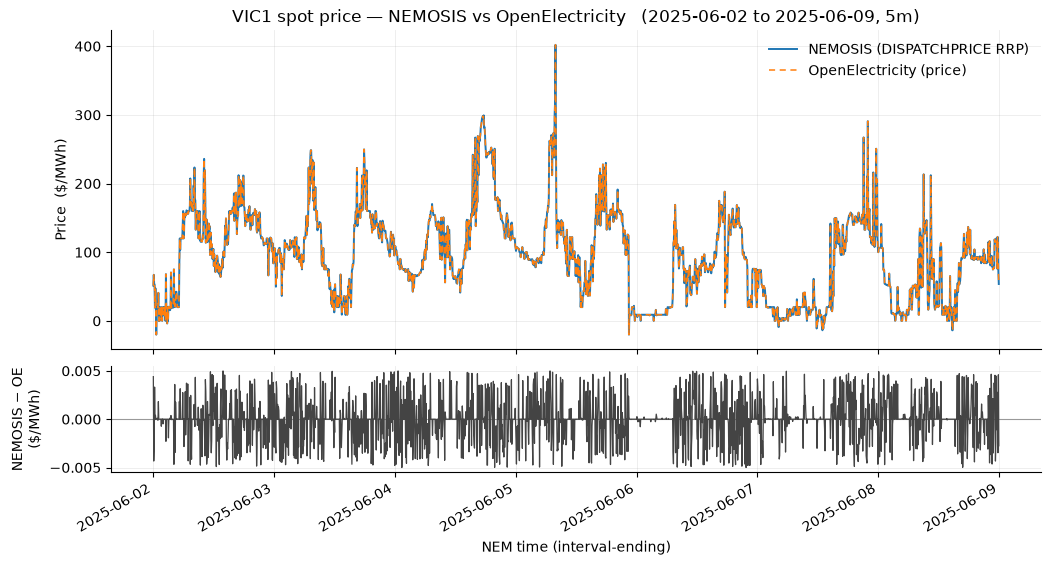

In [5]:
fig, (ax_price, ax_diff) = plt.subplots(
    2, 1, figsize=(12, 6.5), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
)

# Top: both sources overlaid on one shared $/MWh axis. The two series sit almost
# exactly on top of each other, so OE is drawn dashed to let NEMOSIS show through.
ax_price.plot(merged["time"], merged["nemosis"],
              color="#1f77b4", lw=1.4, label="NEMOSIS (DISPATCHPRICE RRP)")
ax_price.plot(merged["time"], merged["openelectricity"],
              color="#ff7f0e", lw=1.1, ls="--", dashes=(4, 3),
              label="OpenElectricity (price)")
ax_price.set_ylabel("Price  ($/MWh)")
ax_price.set_title(
    f"{REGION} spot price — NEMOSIS vs OpenElectricity"
    f"   ({START:%Y-%m-%d} to {END:%Y-%m-%d}, {INTERVAL})"
)
ax_price.legend(frameon=False, loc="upper right")
ax_price.grid(True, alpha=0.25, lw=0.6)

# Bottom: source-to-source difference (own panel, not a 2nd y-axis on the same plot)
ax_diff.axhline(0, color="0.6", lw=0.8)
ax_diff.plot(merged["time"], merged["diff"], color="#444444", lw=0.9)
ax_diff.set_ylabel("NEMOSIS − OE\n($/MWh)")
ax_diff.set_xlabel("NEM time (interval-ending)")
ax_diff.grid(True, alpha=0.25, lw=0.6)

for ax in (ax_price, ax_diff):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.autofmt_xdate()
out = FIGURES / f"smoke_test_{REGION}_{START:%Y%m%d}_{END:%Y%m%d}.png"
fig.savefig(out, dpi=130, bbox_inches="tight")
print("saved:", out.relative_to(PROJECT_ROOT))
plt.show()

## 5. Your read — do the two sources agree, and why?  _(owner writes this)_

This is the point of P0-3, and it's yours to write — CLAUDE.md keeps NEM interpretation
and "whether two data sources agree and why" as owner-only. Use the evidence above; the
numbers and plot are set up, the judgement isn't.

- **Do they agree?** …
- **Where / why do they differ?** (rounding? timestamp convention? window edges? gaps?) …
- **Which source would you trust for what, and why?** …
- **Data traps noticed?** (DST, region code, 5- vs 30-min settlement, silent nulls) …